In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from patsy import dmatrix

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import données

In [4]:
# Sur Google collab (sur le drive) :
from google.colab import drive
drive.mount('/content/drive')
directory = '/content/drive/MyDrive/Datacamp/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
X = pd.read_csv(directory + 'engie_X.csv',
                   header    = 0,
                   index_col = 0,
                   sep       = ';',
                   decimal   = '.')
var_y = pd.read_csv(directory + 'engie_Y.csv',
                   header    = 0,
                   index_col = 0,
                   sep       = ';',
                   decimal   = '.')

In [6]:
var_y.head()

,TARGET
ID,
1,-0.703
2,-0.747
3,-0.791
4,-0.736
5,-1.055


## Data management

In [7]:
# Je renomme la variable d'intérêt Y, je mets en général les X d'un côté et je regarde les types de variables afin de recoder les variables qualitatives
var_y.rename(columns={"TARGET": "Y"}, inplace=True)

Xquanti = X.select_dtypes(exclude=['object'])
Xquali  = X.select_dtypes(include=['object'])
print("Variables quantitatives :", list(Xquanti.columns))
print("Variables qualitatives  :", list(Xquali.columns))

# Encodage one-hot (indicatrices) : drop_first=True évite la colinéarité (supprime la modalité de référence)
XqualiD = pd.get_dummies(Xquali, drop_first=True, dtype=float)
print("Colonne(s) après encodage :", list(XqualiD.columns))

# Base commune : quantitatives + qualitatives encodées
Xbase = pd.concat([Xquanti, XqualiD], axis=1)
print(f"\nNombre de variables dans Xbase : {Xbase.shape[1]}")

Xbase.head()

Variables quantitatives : ['Date_time', 'Pitch_angle', 'Pitch_angle_min', 'Pitch_angle_max', 'Pitch_angle_std', 'Hub_temperature', 'Hub_temperature_min', 'Hub_temperature_max', 'Hub_temperature_std', 'Generator_converter_speed', 'Generator_converter_speed_min', 'Generator_converter_speed_max', 'Generator_converter_speed_std', 'Generator_speed', 'Generator_speed_min', 'Generator_speed_max', 'Generator_speed_std', 'Generator_bearing_1_temperature', 'Generator_bearing_1_temperature_min', 'Generator_bearing_1_temperature_max', 'Generator_bearing_1_temperature_std', 'Generator_bearing_2_temperature', 'Generator_bearing_2_temperature_min', 'Generator_bearing_2_temperature_max', 'Generator_bearing_2_temperature_std', 'Generator_stator_temperature', 'Generator_stator_temperature_min', 'Generator_stator_temperature_max', 'Generator_stator_temperature_std', 'Gearbox_bearing_1_temperature', 'Gearbox_bearing_1_temperature_min', 'Gearbox_bearing_1_temperature_max', 'Gearbox_bearing_1_temperature_st

,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,Generator_converter_speed,...,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c,MAC_CODE_WT2,MAC_CODE_WT3,MAC_CODE_WT4
ID,,,,,,,,,,,,,,,,,,,,,
1,1.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.38,...,0.0,2.4,2.4,2.4,0.0,294.19000,294.23999,0.0,1.0,0.0
2,2.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.56,...,0.0,2.4,2.4,2.4,0.0,297.82999,294.23999,0.0,1.0,0.0
3,3.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.51,...,0.0,2.4,2.4,2.4,0.0,322.20999,294.23999,0.0,1.0,0.0
4,4.0,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,0.02,4.06,...,0.0,2.4,2.4,2.4,0.0,318.69000,294.23999,0.0,1.0,0.0
5,5.0,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,0.17,3.61,...,0.0,2.4,2.4,2.5,0.0,314.89001,294.23999,0.0,1.0,0.0


In [8]:
# merge des 2 bases
df = pd.merge(Xbase, var_y, left_index=True, right_index=True)
df.head()

,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,Generator_converter_speed,...,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c,MAC_CODE_WT2,MAC_CODE_WT3,MAC_CODE_WT4,Y
ID,,,,,,,,,,,,,,,,,,,,,
1,1.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.38,...,2.4,2.4,2.4,0.0,294.19000,294.23999,0.0,1.0,0.0,-0.703
2,2.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.56,...,2.4,2.4,2.4,0.0,297.82999,294.23999,0.0,1.0,0.0,-0.747
3,3.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.51,...,2.4,2.4,2.4,0.0,322.20999,294.23999,0.0,1.0,0.0,-0.791
4,4.0,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,0.02,4.06,...,2.4,2.4,2.4,0.0,318.69000,294.23999,0.0,1.0,0.0,-0.736
5,5.0,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,0.17,3.61,...,2.4,2.4,2.5,0.0,314.89001,294.23999,0.0,1.0,0.0,-1.055


# Description de la base

### Commandes génériques pour la description d'un DataFrame

Voici quelques commandes utiles pour obtenir une vue d'ensemble rapide de votre DataFrame `df`:

1.  **`df.info()`** : Fournit un résumé concis du DataFrame, y compris le nombre de lignes, le nombre de colonnes, les types de données de chaque colonne, le nombre de valeurs non-nulles et l'utilisation de la mémoire. C'est excellent pour vérifier les types et les valeurs manquantes.
2.  **`df.describe()`** : Génère des statistiques descriptives (moyenne, écart-type, min, max, quartiles) pour les colonnes numériques. Pour les colonnes d'objets (comme les chaînes de caractères), il fournit le nombre unique, la valeur la plus fréquente, etc. Utilisez `df.describe(include='all')` pour inclure toutes les colonnes (numériques et catégorielles).
3.  **`df.head()` / `df.tail()`** : Affiche les premières/dernières lignes du DataFrame, utile pour une inspection rapide des données.
4.  **`df.shape`** : Renvoie un tuple représentant les dimensions du DataFrame (nombre de lignes, nombre de colonnes).
5.  **`df.isnull().sum()`** : Calcule le nombre de valeurs manquantes par colonne.
6.  **`df.dtypes`** : Affiche les types de données de chaque colonne.

In [9]:
print("--- Aperçu des premières lignes du DataFrame ---")
display(df.head())

print("\n--- Informations générales sur le DataFrame (types, non-null) ---")
df.info()

print("\n--- Statistiques descriptives ---")
display(df.describe())

print("\n--- Dimensions du DataFrame (lignes, colonnes) ---")
print(df.shape)

print("\n--- Types de données des colonnes ---")
display(df.dtypes)

--- Aperçu des premières lignes du DataFrame ---


,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,Generator_converter_speed,...,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c,MAC_CODE_WT2,MAC_CODE_WT3,MAC_CODE_WT4,Y
ID,,,,,,,,,,,,,,,,,,,,,
1,1.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.38,...,2.4,2.4,2.4,0.0,294.19000,294.23999,0.0,1.0,0.0,-0.703
2,2.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.56,...,2.4,2.4,2.4,0.0,297.82999,294.23999,0.0,1.0,0.0,-0.747
3,3.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.51,...,2.4,2.4,2.4,0.0,322.20999,294.23999,0.0,1.0,0.0,-0.791
4,4.0,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,0.02,4.06,...,2.4,2.4,2.4,0.0,318.69000,294.23999,0.0,1.0,0.0,-0.736
5,5.0,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,0.17,3.61,...,2.4,2.4,2.5,0.0,314.89001,294.23999,0.0,1.0,0.0,-1.055



--- Informations générales sur le DataFrame (types, non-null) ---
<class 'pandas.core.frame.DataFrame'>
Index: 617386 entries, 1 to 617386
Data columns (total 80 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Date_time                            617386 non-null  float64
 1   Pitch_angle                          617386 non-null  float64
 2   Pitch_angle_min                      617386 non-null  float64
 3   Pitch_angle_max                      617386 non-null  float64
 4   Pitch_angle_std                      617386 non-null  float64
 5   Hub_temperature                      617386 non-null  float64
 6   Hub_temperature_min                  617386 non-null  float64
 7   Hub_temperature_max                  617386 non-null  float64
 8   Hub_temperature_std                  617386 non-null  float64
 9   Generator_converter_speed            609322 non-null  float64
 10  Generator_converte

,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,Generator_converter_speed,...,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c,MAC_CODE_WT2,MAC_CODE_WT3,MAC_CODE_WT4,Y
count,617386.000000,617386.000000,617386.000000,617386.000000,617386.000000,617386.000000,617386.000000,617386.000000,617386.000000,609322.000000,...,617386.000000,617386.000000,617386.000000,617386.00000,617314.000000,617314.000000,617386.000000,617386.000000,617386.000000,617386.000000
mean,79862.855363,13.011933,11.798694,14.547896,0.948836,19.148534,18.940682,19.356001,0.106900,1065.451335,...,28.417645,28.319655,28.503478,0.04733,174.828981,175.538522,0.250720,0.249849,0.248848,372.752158
std,45185.110967,27.237490,27.054199,28.005869,4.208172,6.601252,6.625706,6.600733,0.156876,601.015642,...,7.257950,7.265970,7.290289,0.13126,96.087881,96.773179,0.433428,0.432926,0.432346,468.001341
min,1.000000,-156.179990,-179.570010,-146.280000,0.000000,-4.000000,-5.000000,-3.000000,0.000000,0.000000,...,-5.200000,-5.200000,-5.100000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.479999
25%,41154.000000,-1.000000,-1.010000,-1.000000,0.000000,14.000000,14.000000,14.000000,0.000000,925.150020,...,25.600000,25.500000,25.700001,0.02000,80.669998,79.660004,0.000000,0.000000,0.000000,18.624000
50%,80145.000000,-1.000000,-1.000000,-1.000000,0.000000,19.990000,19.200001,20.000000,0.000000,1175.000000,...,29.600000,29.500000,29.700001,0.04000,191.740010,193.270000,0.000000,0.000000,0.000000,193.985989
75%,119014.000000,5.567500,-0.980000,15.900000,0.000000,24.000000,24.000000,24.000000,0.210000,1563.160000,...,33.009998,32.900002,33.099998,0.07000,245.810000,248.030000,1.000000,0.000000,0.000000,540.684000
max,157680.000000,156.820010,175.929990,175.929990,94.769997,37.080002,37.000000,38.000000,1.240000,1806.560100,...,67.669998,53.500000,393.799990,98.57000,360.000000,360.000000,1.000000,1.000000,1.000000,2256.057110



--- Dimensions du DataFrame (lignes, colonnes) ---
(617386, 80)

--- Types de données des colonnes ---


,0
Date_time,float64
Pitch_angle,float64
Pitch_angle_min,float64
Pitch_angle_max,float64
Pitch_angle_std,float64
...,...
Nacelle_angle_c,float64
MAC_CODE_WT2,float64
MAC_CODE_WT3,float64
MAC_CODE_WT4,float64


Focus valeurs manquantes

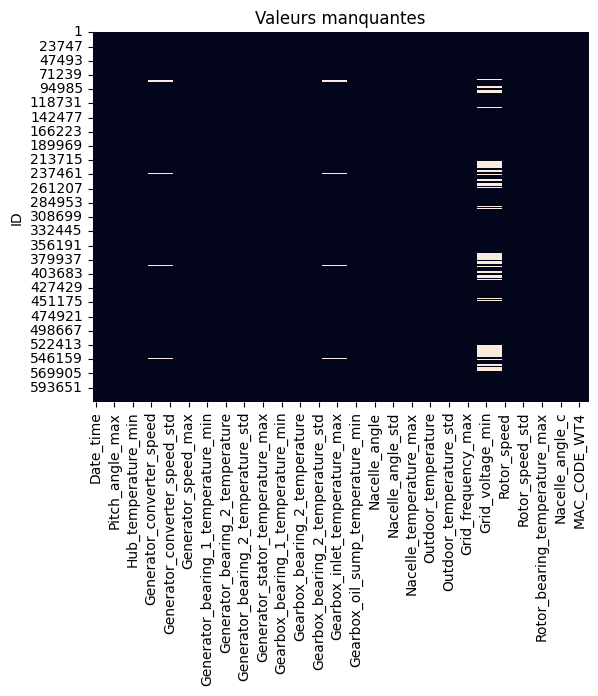

In [14]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Valeurs manquantes')
plt.show()

In [15]:
missing_percentage = df.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
Grid_voltage                     16.411451
Grid_voltage_min                 16.411451
Grid_voltage_max                 16.411451
Grid_voltage_std                 16.411451
Generator_converter_speed         1.306152
Generator_converter_speed_min     1.306152
Gearbox_inlet_temperature_min     1.306152
Gearbox_inlet_temperature         1.306152
Generator_converter_speed_std     1.306152
Generator_converter_speed_max     1.306152
Gearbox_inlet_temperature_max     1.306152
Gearbox_inlet_temperature_std     1.306152
Absolute_wind_direction_c         0.011662
Nacelle_angle_c                   0.011662
dtype: float64


--- Boxplots pour toutes les colonnes numériques (vue d'ensemble) ---


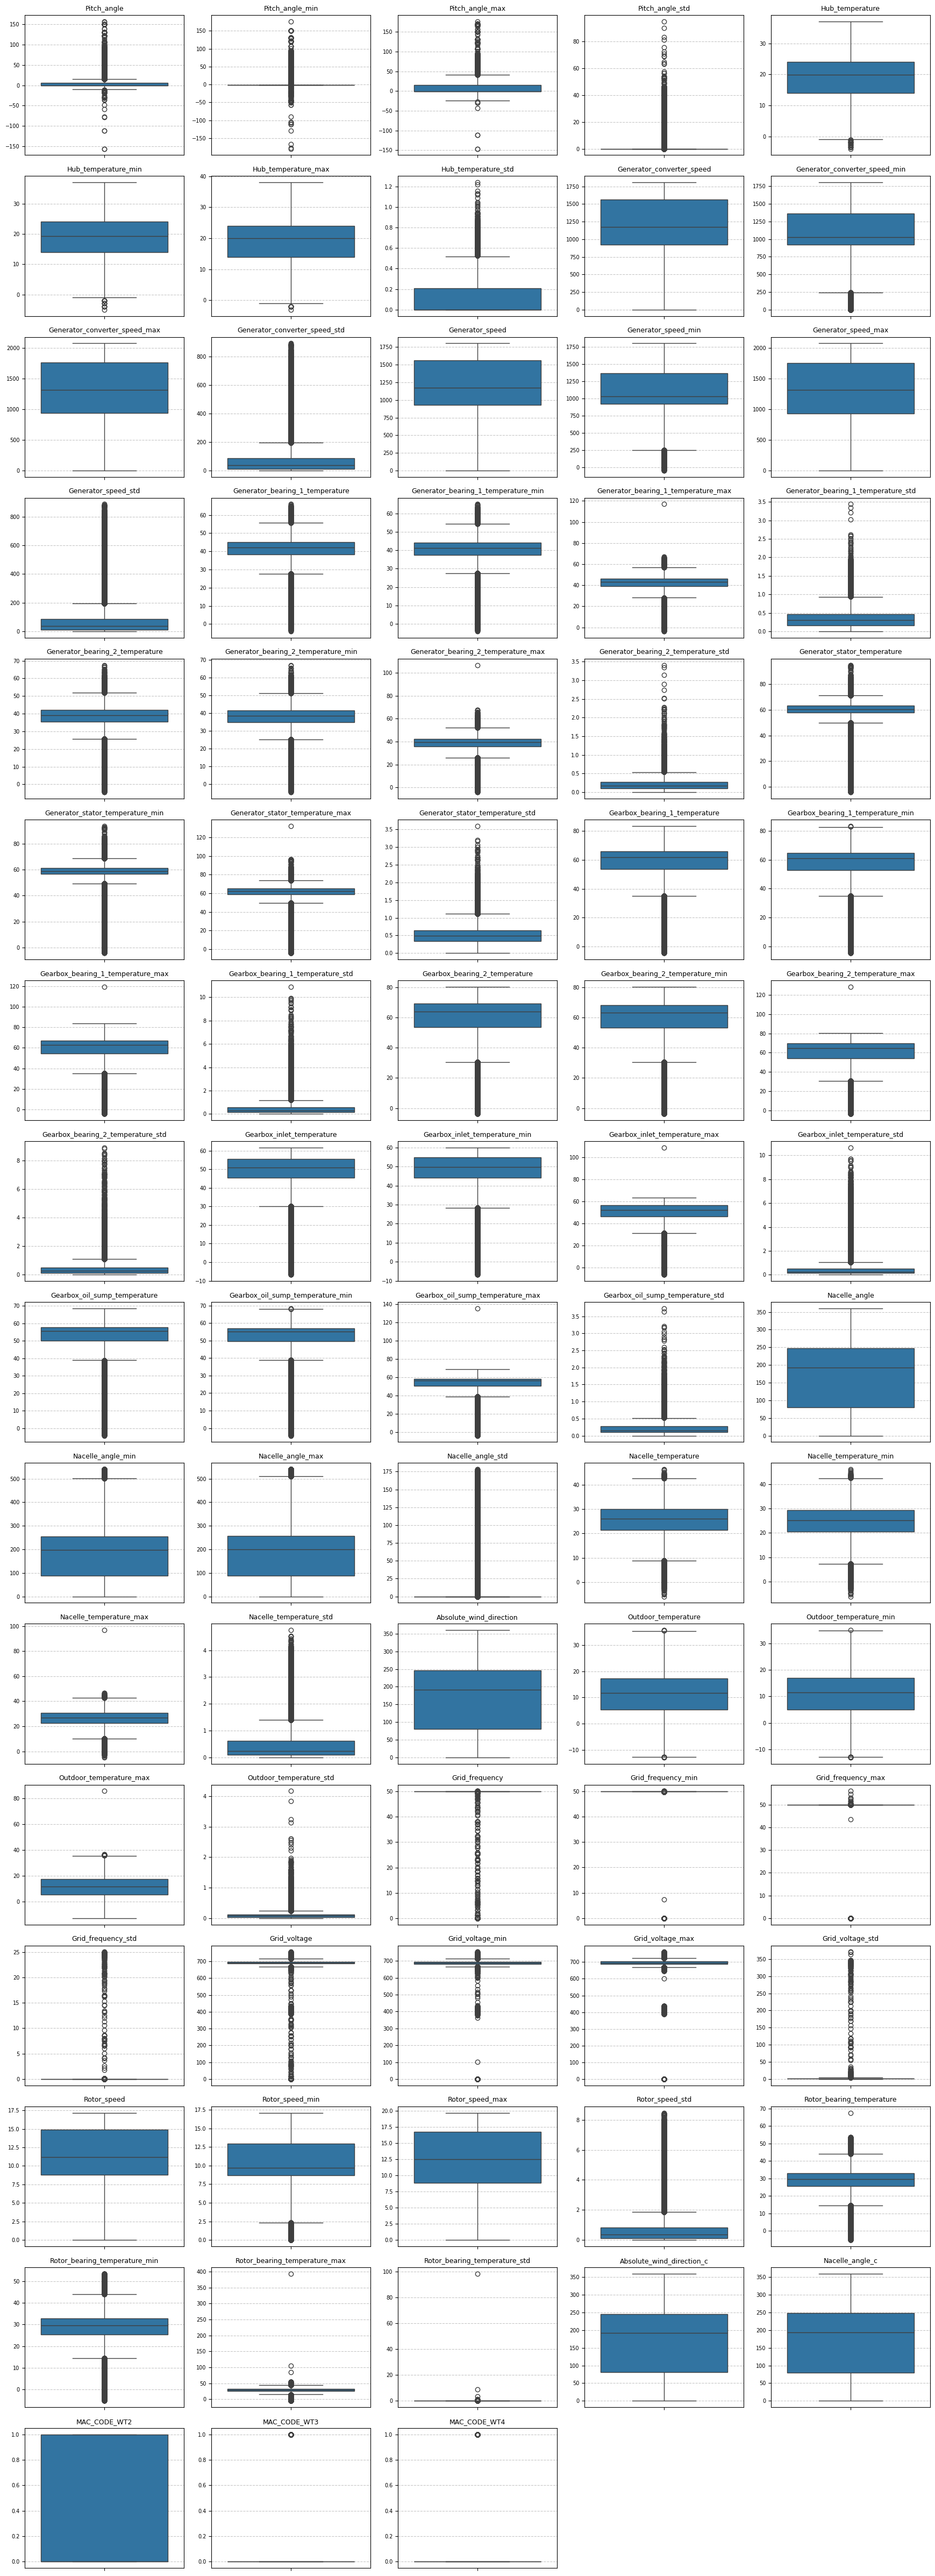

In [26]:

import seaborn as sns

# Sélectionner uniquement les colonnes numériques pour les boxplots
numerical_cols = df.select_dtypes(include=np.number).columns

# Exclure les colonnes qui sont des identifiants ou n'ont pas de variance significative pour les boxplots
# 'Date_time' est un float mais pourrait être traité différemment ou exclu si c'est un identifiant temporel
columns_for_overview = [col for col in numerical_cols if col not in ['Date_time', 'ID', 'Y']]

# Utiliser TOUTES les colonnes sélectionnées pour la grille de boxplots
columns_to_plot_grid = columns_for_overview

# Calculer le nombre de lignes et de colonnes pour la grille
n_cols = 5  # Nombre de colonnes par ligne dans la grille (peut être ajusté)
n_rows = (len(columns_to_plot_grid) + n_cols - 1) // n_cols # Calcul pour avoir assez de lignes

# Ajuster la taille de la figure pour accueillir plus de plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3))
axes = axes.flatten() # Aplatir l'array d'axes pour faciliter l'itération

print("--- Boxplots pour toutes les colonnes numériques (vue d'ensemble) ---")
for i, col in enumerate(columns_to_plot_grid):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9) # Titre plus petit pour les sous-graphes
    axes[i].set_ylabel('') # Supprimer le label de l'axe y pour éviter l'encombrement
    axes[i].tick_params(axis='y', labelsize=7) # Ajuster la taille des ticks y
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Masquer les axes vides s'il y en a
for j in range(len(columns_to_plot_grid), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Ajuster l'espacement entre les sous-graphes
plt.show()

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identifier les colonnes quantitatives à inclure dans les plots
# Exclure 'Date_time', 'ID', et 'Y' (variable cible)
quantitative_cols_to_plot = [col for col in df.select_dtypes(include=np.number).columns if col not in ['Date_time', 'ID', 'Y']]

# Configurer la grille des sous-plots
n_cols = 4  # Nombre de colonnes par ligne dans la grille (ajuster si nécessaire)
n_rows = (len(quantitative_cols_to_plot) + n_cols - 1) // n_cols # Calcul pour avoir assez de lignes

# Ajuster la taille de la figure pour accueillir tous les plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 3.5))
axes = axes.flatten() # Aplatir l'array d'axes pour faciliter l'itération

print("--- Scatter plots 1D pour les variables quantitatives (points colorés par valeurs manquantes dans d'autres variables) ---")

for i, col in enumerate(quantitative_cols_to_plot):
    ax = axes[i]

    # Déterminer les colonnes à vérifier pour les valeurs manquantes pour cette itération
    # Ce sont toutes les colonnes SAUF la colonne actuelle 'col' et les colonnes exclues globalement
    cols_to_check_for_missing = [c for c in df.columns if c not in [col, 'Date_time', 'ID', 'Y']]

    # Calculer si une ligne a DES valeurs manquantes dans ces 'autres' colonnes
    # On ne considère que les lignes où la colonne actuelle n'est pas NaN pour le tracé
    has_other_missing = df.loc[df[col].notna(), cols_to_check_for_missing].isnull().any(axis=1)

    # Convertir le booléen en étiquettes significatives pour la légende
    hue_labels = has_other_missing.map({True: 'Manquants dans autres vars', False: 'Pas de manquants ailleurs'})

    # Préparer les données pour le stripplot, en incluant seulement les valeurs non-NaN de la colonne actuelle
    plot_data = pd.DataFrame({
        'value': df.loc[df[col].notna(), col],
        'has_missing': hue_labels
    })

    # Utiliser stripplot pour un scatter plot 1D avec jitter
    sns.stripplot(y='value', x=np.zeros(len(plot_data)), data=plot_data, hue='has_missing',
                  jitter=0.2, ax=ax, palette={'Manquants dans autres vars': 'red', 'Pas de manquants ailleurs': 'blue'},
                  alpha=0.4, legend=False)

    ax.set_title(col, fontsize=9)
    ax.set_ylabel('') # Supprimer le label y pour éviter l'encombrement
    ax.set_xlabel('') # Supprimer le label x
    ax.set_xticks([]) # Supprimer les ticks x
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Ajouter une légende seulement au premier plot pour éviter la répétition
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, title="État des manquants", bbox_to_anchor=(1.02, 0.95), loc='upper left', borderaxespad=0.)

# Masquer les axes vides s'il y en a
for j in range(len(quantitative_cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajuster l'espacement et laisser de la place pour la légende globale
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Cette visualisation vous permet de voir rapidement la distribution et l'étendue des valeurs atypiques pour plusieurs variables en un coup d'œil. Pour une analyse plus détaillée de chaque colonne avec le décompte précis des outliers, vous pouvez utiliser la fonction `plot_boxplot_with_outliers` définie précédemment sur une colonne spécifique.